# 8단계 · Walk-Forward Optimization

## 왜 Walk-Forward인가?

| 방법 | 문제 | 결과 |
|------|------|------|
| **동일 데이터에서 ADX 탐색** | 과거 정답 암기 (과적합) | 실전 성과 급락 |
| **Walk-Forward** | 학습/검증 구간 분리 → 미래 데이터 미사용 | 실전에 가까운 성과 |

```
[ 학습 12개월 → 최적 ADX 탐색 ] [ 검증 6개월 → 그 ADX로 실제 거래 ]
                 [ 학습 12개월 → 최적 ADX 탐색 ] [ 검증 6개월 ]
                                  [ 학습 12개월 ] [ 검증 6개월 ]
                                                   ...
```

## 학습 12개월 / 검증 6개월을 선택한 이유

- MA120(6개월 이동평균) warm-up에 최소 120거래일 필요
- 학습 6개월(~126일)이면 MA120 제외 후 실제 신호가 거의 없음
- **학습 12개월 → 충분한 신호 + MA warm-up 여유**
- 검증 6개월 → 시장 국면 한 사이클(상승/조정/하락) 포함 가능

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import vectorbt as vbt
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from vbt_backtest import optimizer
from vbt_backtest.config import (
    FEES, SLIPPAGE,
    ADX_PARAM_GRID, WF_TRAIN_MONTHS, WF_TEST_MONTHS,
    ADX_THRESHOLD_DEFAULT, ADX_SIDEWAYS_DEFAULT,
)
from vbt_backtest.strategies.combined import ma_regime_strategy

# ── 데이터 로드 ───────────────────────────────────────────────────────────────
TICKER = '005930.KS'
START  = '2019-01-01'
END    = '2024-12-31'

df = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

close  = df['Close'].squeeze()
high   = df['High'].squeeze()
low    = df['Low'].squeeze()
volume = df['Volume'].squeeze()

print(f'종목  : 삼성전자 ({TICKER})')
print(f'기간  : {close.index[0].date()} ~ {close.index[-1].date()}')
print(f'거래일: {len(close)}일')
print(f'시작가: {close.iloc[0]:,.0f}원  /  종가: {close.iloc[-1]:,.0f}원')

종목  : 삼성전자 (005930.KS)
기간  : 2019-01-02 ~ 2024-12-30
거래일: 1475일
시작가: 32,297원  /  종가: 51,969원


---
## 1단계 · Walk-Forward 실행

- **최적화 파라미터**: `adx_threshold` (추세 판별 임계값) + `adx_sideways` (횡보 판별 임계값)
- **탐색 범위**: adx_threshold [15, 20, 25, 30] × adx_sideways [10, 15, 20] → 12가지 조합
- **최적화 기준**: 샤프비율 (리스크 대비 수익 최대화)
- **학습**: 12개월 / **검증**: 6개월


In [2]:

# ── strategy_fn 래퍼: walk_forward의 일반 인터페이스에 맞게 ───────────────────
def regime_fn(close, high, low, volume=None, adx_threshold=25.0, adx_sideways=20.0,
              fees=FEES, slippage=SLIPPAGE):
    return ma_regime_strategy.run_backtest(
        close, high, low,
        adx_threshold=adx_threshold,
        adx_sideways=adx_sideways,
        fees=fees, slippage=slippage,
    )

# ── Walk-Forward 실행 ─────────────────────────────────────────────────────────
print('Walk-Forward 최적화 실행 중... (학습 12개월 / 검증 6개월)')
wf_result = optimizer.walk_forward(
    close,
    regime_fn,
    param_grid=ADX_PARAM_GRID,
    train_months=WF_TRAIN_MONTHS,
    test_months=WF_TEST_MONTHS,
    fees=FEES,
    slippage=SLIPPAGE,
    metric='sharpe_ratio',
    warmup_days=150,
    high=high, low=low, volume=volume,
)

print(f'완료: 총 {wf_result["n_windows"]}개 윈도우')


Walk-Forward 최적화 실행 중... (학습 12개월 / 검증 6개월)
완료: 총 9개 윈도우


---
## 2단계 · 구간별 최적 ADX 임계값 확인

In [3]:
rows = []
for i, w in enumerate(wf_result['windows']):
    rows.append({
        '윈도우':      f'W{i+1:02d}',
        '학습 시작':   w['train_start'].strftime('%Y-%m'),
        '학습 종료':   w['train_end'].strftime('%Y-%m'),
        '검증 시작':   w['test_start'].strftime('%Y-%m'),
        '검증 종료':   w['test_end'].strftime('%Y-%m'),
        'threshold':   w['best_params']['adx_threshold'],
        'sideways':    w['best_params']['adx_sideways'],
        '학습 샤프':   round(w['best_score'], 3),
        '검증 수익률': f"{(w['test_value'].iloc[-1] / w['test_value'].iloc[0] - 1):.2%}"
                       if w['test_value'] is not None and len(w['test_value']) > 0
                       else 'N/A',
    })

df_windows = pd.DataFrame(rows).set_index('윈도우')
print('=== 구간별 Walk-Forward 결과 ===')
print(df_windows.to_string())

th_vals = [w['best_params']['adx_threshold'] for w in wf_result['windows']]
sw_vals = [w['best_params']['adx_sideways']  for w in wf_result['windows']]
print(f'\nadx_threshold 최빈값: {max(set(th_vals), key=th_vals.count)}')
print(f'adx_sideways  최빈값: {max(set(sw_vals), key=sw_vals.count)}')


=== 구간별 Walk-Forward 결과 ===
       학습 시작    학습 종료    검증 시작    검증 종료  최적 ADX  학습 샤프    검증 수익률
윈도우                                                             
W01  2019-01  2020-01  2020-01  2020-07      15    2.089   0.00%
W02  2019-07  2020-07  2020-07  2020-12      15     -inf  22.21%
W03  2020-01  2021-01  2021-01  2021-07      15    1.950  -1.64%
W04  2020-07  2021-07  2021-07  2021-12      15    2.098  -0.61%
W05  2021-01  2022-01  2022-01  2022-07      15   -0.052   0.00%
W06  2021-07  2022-07  2022-07  2022-12      15     -inf  -1.01%
W07  2022-01  2023-01  2023-01  2023-06      15   -0.121  15.76%
W08  2022-07  2023-07  2023-07  2023-12      15    1.583   9.27%
W09  2023-01  2024-01  2024-01  2024-07      15    2.382   2.02%

최적 ADX 평균: 15.0  /  표준편차: 0.0
분포: {15: 9}


---
## 3단계 · 최적 ADX 임계값 변화 시각화

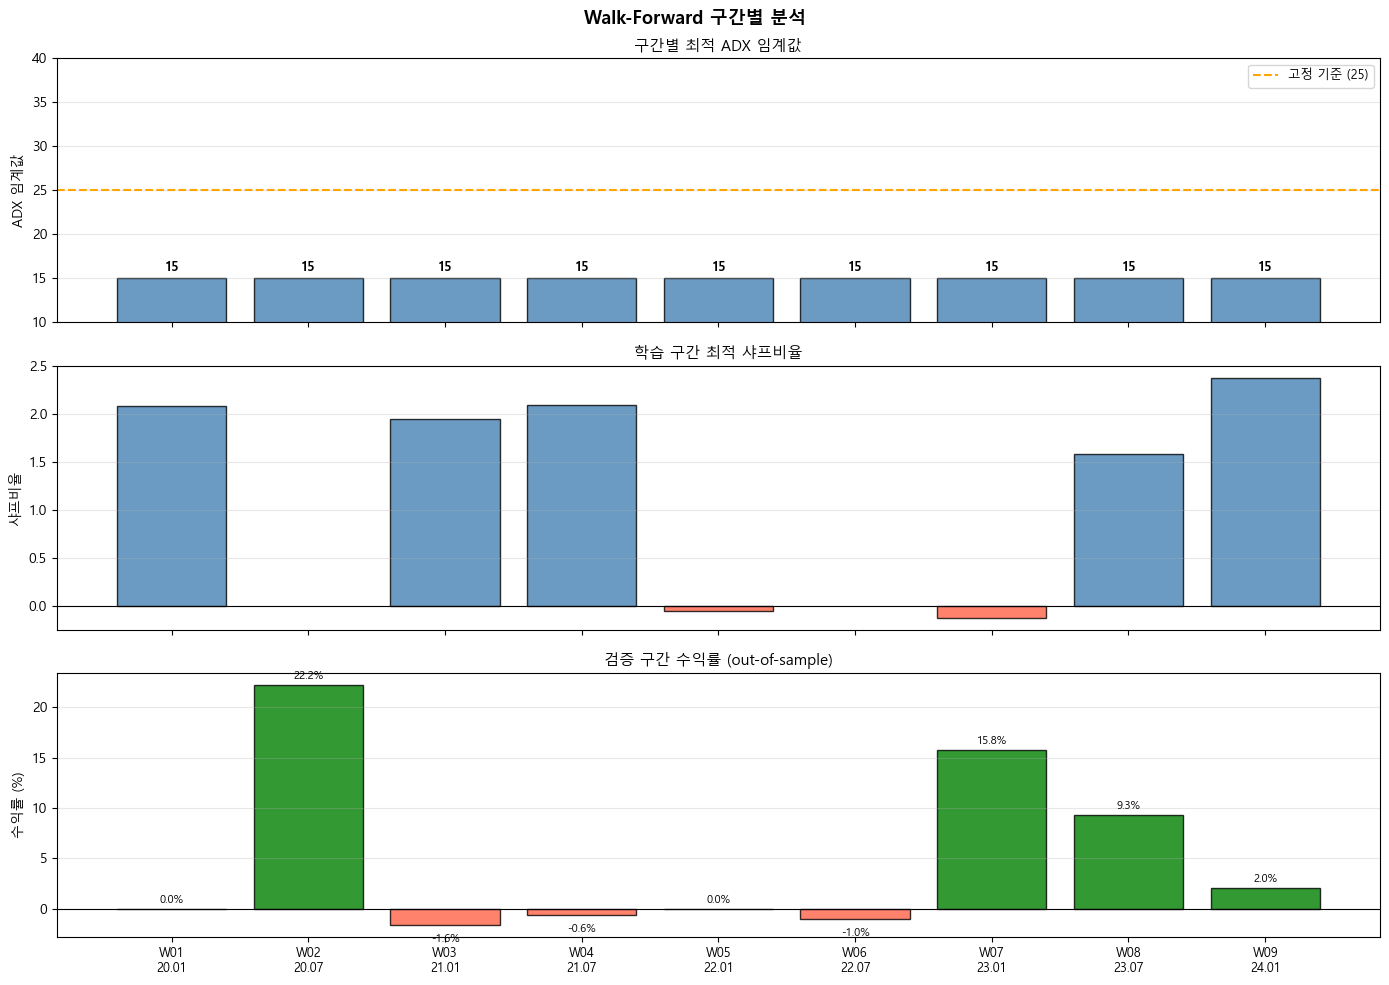

In [4]:
windows     = wf_result['windows']
n           = len(windows)
labels      = [f"W{i+1:02d}\n{w['test_start'].strftime('%y.%m')}" for i, w in enumerate(windows)]
adx_th_vals = [w['best_params']['adx_threshold'] for w in windows]
adx_sw_vals = [w['best_params']['adx_sideways']  for w in windows]
train_sharp = [w['best_score'] for w in windows]
test_rets   = [
    (w['test_value'].iloc[-1] / w['test_value'].iloc[0] - 1) * 100
    if w['test_value'] is not None and len(w['test_value']) > 0 else 0
    for w in windows
]

fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)

# ① adx_threshold
bars = axes[0].bar(range(n), adx_th_vals, color='steelblue', alpha=0.8, edgecolor='black')
axes[0].axhline(25, color='orange', lw=1.5, ls='--', label='업계 표준 (25)')
axes[0].set_title('구간별 최적 adx_threshold', fontsize=11)
axes[0].set_ylabel('adx_threshold')
axes[0].set_ylim(10, 35)
axes[0].legend(fontsize=9)
for bar, val in zip(bars, adx_th_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

# ② adx_sideways
bars2 = axes[1].bar(range(n), adx_sw_vals, color='mediumpurple', alpha=0.8, edgecolor='black')
axes[1].axhline(20, color='orange', lw=1.5, ls='--', label='기존 고정값 (20)')
axes[1].set_title('구간별 최적 adx_sideways', fontsize=11)
axes[1].set_ylabel('adx_sideways')
axes[1].set_ylim(5, 30)
axes[1].legend(fontsize=9)
for bar, val in zip(bars2, adx_sw_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

# ③ 학습 샤프
axes[2].bar(range(n), train_sharp, color='seagreen', alpha=0.8, edgecolor='black')
axes[2].set_title('학습 구간 Sharpe Ratio', fontsize=11)
axes[2].set_ylabel('Sharpe')
for i, v in enumerate(train_sharp):
    if np.isfinite(v):
        axes[2].text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=8)

# ④ 검증 수익률
colors = ['crimson' if r >= 0 else 'gray' for r in test_rets]
axes[3].bar(range(n), test_rets, color=colors, alpha=0.8, edgecolor='black')
axes[3].axhline(0, color='black', lw=0.8)
axes[3].set_title('검증 구간 수익률 (%)', fontsize=11)
axes[3].set_ylabel('수익률 (%)')
axes[3].set_xticks(range(n))
axes[3].set_xticklabels(labels, fontsize=9)

plt.suptitle('Walk-Forward 최적화 결과 (adx_threshold + adx_sideways)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 4단계 · 자산 곡선 비교: Walk-Forward vs Buy & Hold vs 고정 ADX=25

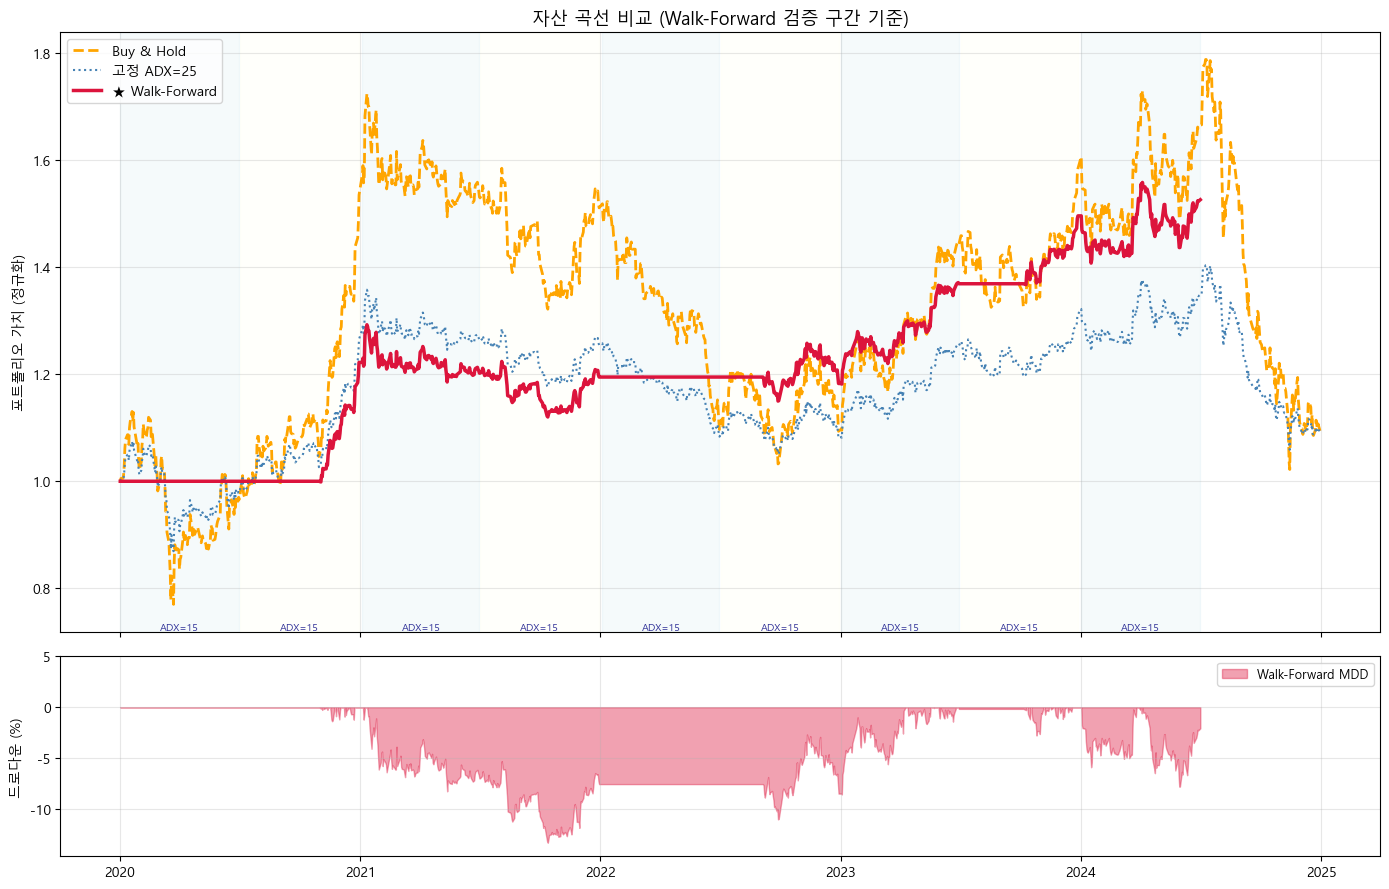

In [5]:
# ── 고정 ADX=25 전략 (전체 구간) ──────────────────────────────────────────────
pf_fixed = ma_regime_strategy.run_backtest(
    close, high, low,
    adx_threshold=25.0, adx_sideways=20.0, fees=FEES, slippage=SLIPPAGE,
)

# ── Buy & Hold ────────────────────────────────────────────────────────────────
bh_e = pd.Series(False, index=close.index); bh_e.iloc[0] = True
bh_x = pd.Series(False, index=close.index); bh_x.iloc[-1] = True
pf_bh = vbt.Portfolio.from_signals(close, bh_e, bh_x, fees=FEES, slippage=SLIPPAGE, freq='D')

# ── Walk-Forward 자산 곡선 (검증 구간 이어붙임) ───────────────────────────────
wf_equity = wf_result['equity_curve']

# 공통 시작 시점 맞추기 (Walk-Forward 첫 검증 시작일)
wf_start = wf_equity.index[0]

fixed_value = pf_fixed.value()
fixed_norm  = fixed_value / fixed_value.loc[wf_start] * wf_equity.iloc[0]
fixed_norm  = fixed_norm.loc[wf_start:]

bh_value = pf_bh.value()
bh_norm  = bh_value / bh_value.loc[wf_start] * wf_equity.iloc[0]
bh_norm  = bh_norm.loc[wf_start:]

# ── 시각화 ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9),
                                gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax1.plot(bh_norm,    color='orange',    linewidth=2.0, linestyle='--', label=f'Buy & Hold')
ax1.plot(fixed_norm, color='steelblue', linewidth=1.5, linestyle=':',  label=f'고정 ADX=25')
ax1.plot(wf_equity,  color='crimson',   linewidth=2.5, linestyle='-',  label='★ Walk-Forward')

# 검증 구간 배경 표시
for i, w in enumerate(wf_result['windows']):
    color = 'lightblue' if i % 2 == 0 else 'lightyellow'
    ax1.axvspan(w['test_start'], w['test_end'], alpha=0.12, color=color)
    ax1.text(w['test_start'] + (w['test_end'] - w['test_start']) / 2,
             ax1.get_ylim()[0] if ax1.get_ylim()[0] > 0 else 1.0,
             f"ADX={w['best_params']['adx_threshold']}",
             ha='center', va='bottom', fontsize=7.5, color='navy', alpha=0.8)

ax1.set_title('자산 곡선 비교 (Walk-Forward 검증 구간 기준)', fontsize=13)
ax1.set_ylabel('포트폴리오 가치 (정규화)')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# 하단: Walk-Forward 드로다운
wf_dd = (wf_equity / wf_equity.cummax() - 1) * 100
ax2.fill_between(wf_dd.index, 0, wf_dd, color='crimson', alpha=0.4, label='Walk-Forward MDD')
ax2.set_ylabel('드로다운 (%)')
ax2.set_ylim(wf_dd.min() * 1.1, 5)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5단계 · 성과 비교 테이블

In [6]:
# Walk-Forward 기간과 동일한 구간으로 비교
wf_start = wf_equity.index[0]
wf_end   = wf_equity.index[-1]

close_wf = close.loc[wf_start:wf_end]

# Buy & Hold (같은 기간)
bh_e2 = pd.Series(False, index=close_wf.index); bh_e2.iloc[0] = True
bh_x2 = pd.Series(False, index=close_wf.index); bh_x2.iloc[-1] = True
pf_bh2 = vbt.Portfolio.from_signals(
    close_wf, bh_e2, bh_x2, fees=FEES, slippage=SLIPPAGE, freq='D'
)

# 고정 ADX=25 (같은 기간)
pf_fixed2 = ma_regime_strategy.run_backtest(
    close_wf,
    high.loc[wf_start:wf_end],
    low.loc[wf_start:wf_end],
    volume.loc[wf_start:wf_end],
    adx_threshold=25.0, fees=FEES, slippage=SLIPPAGE,
)

# Walk-Forward 지표 계산 (이어붙인 equity curve 기반)
wf_total_return     = wf_equity.iloc[-1] / wf_equity.iloc[0] - 1
n_years             = (wf_end - wf_start).days / 365.25
wf_cagr             = (wf_equity.iloc[-1] / wf_equity.iloc[0]) ** (1 / n_years) - 1
wf_daily_ret        = wf_equity.pct_change().dropna()
wf_sharpe           = wf_daily_ret.mean() / wf_daily_ret.std() * np.sqrt(252)
wf_mdd              = (wf_equity / wf_equity.cummax() - 1).min()

rows = [
    {
        '전략':         'Buy & Hold',
        '총 수익률':    f"{pf_bh2.total_return():.2%}",
        '연평균(CAGR)': f"{pf_bh2.annualized_return():.2%}",
        '샤프비율':     f"{pf_bh2.sharpe_ratio():.2f}",
        '최대낙폭':     f"{pf_bh2.max_drawdown():.2%}",
    },
    {
        '전략':         '고정 ADX=25',
        '총 수익률':    f"{pf_fixed2.total_return():.2%}",
        '연평균(CAGR)': f"{pf_fixed2.annualized_return():.2%}",
        '샤프비율':     f"{pf_fixed2.sharpe_ratio():.2f}",
        '최대낙폭':     f"{pf_fixed2.max_drawdown():.2%}",
    },
    {
        '전략':         '★ Walk-Forward',
        '총 수익률':    f"{wf_total_return:.2%}",
        '연평균(CAGR)': f"{wf_cagr:.2%}",
        '샤프비율':     f"{wf_sharpe:.2f}",
        '최대낙폭':     f"{wf_mdd:.2%}",
    },
]

df_compare = pd.DataFrame(rows).set_index('전략')
print(f'=== 성과 비교 ({wf_start.date()} ~ {wf_end.date()}) ===')
print(df_compare.to_string())
print()
print(f'* Walk-Forward 검증 윈도우 수: {wf_result["n_windows"]}개')
print(f'* 사용된 ADX 임계값: {[w["best_params"]["adx_threshold"] for w in wf_result["windows"]]}') 

=== 성과 비교 (2020-01-02 ~ 2024-07-01) ===
                 총 수익률 연평균(CAGR)  샤프비율     최대낙폭
전략                                             
Buy & Hold      65.77%    18.13%  0.70  -40.14%
고정 ADX=25       34.42%    10.25%  0.71  -22.62%
★ Walk-Forward  52.61%     9.86%  1.02  -13.33%

* Walk-Forward 검증 윈도우 수: 9개
* 사용된 ADX 임계값: [15, 15, 15, 15, 15, 15, 15, 15, 15]


---
## 6단계 · 학습 구간 그리드 서치 결과 상세

각 윈도우에서 어떤 ADX 값들이 어떤 샤프비율을 냈는지 확인합니다.

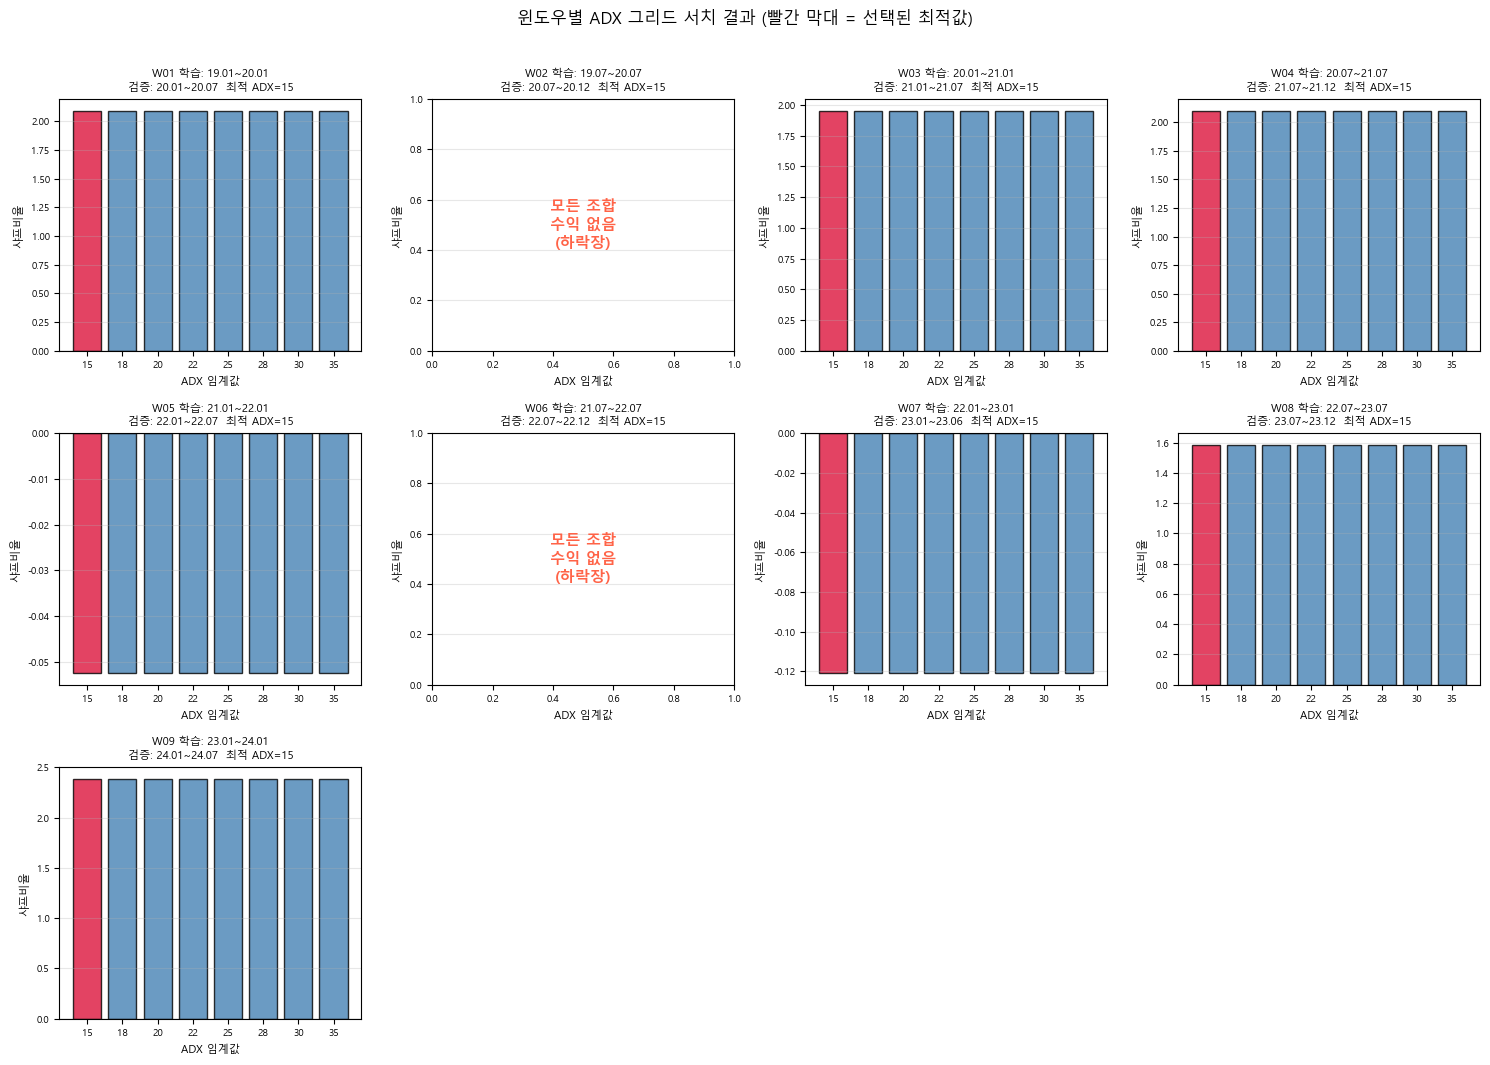

In [7]:
import seaborn as sns

n_windows = len(wf_result['windows'])
ncols = 3
nrows = (n_windows + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes_flat = axes.flatten() if n_windows > 1 else [axes]

for i, w in enumerate(wf_result['windows']):
    ax = axes_flat[i]
    scan_df = w['scan'].copy()
    if scan_df.empty:
        ax.set_visible(False)
        continue

    best_th = w['best_params']['adx_threshold']
    best_sw = w['best_params']['adx_sideways']

    try:
        pivot = scan_df.pivot_table(
            index='adx_sideways', columns='adx_threshold', values='sharpe_ratio'
        )
        sns.heatmap(
            pivot, ax=ax, cmap='RdYlGn', center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'shrink': 0.8},
        )
    except Exception:
        ax.set_visible(False)
        continue

    ax.set_title(
        f'W{i+1:02d} | {w["test_start"].strftime("%y.%m")}~{w["test_end"].strftime("%y.%m")}\n'
        f'최적: threshold={best_th}, sideways={best_sw}',
        fontsize=9,
    )
    ax.set_xlabel('adx_threshold', fontsize=8)
    ax.set_ylabel('adx_sideways', fontsize=8)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('학습 구간 그리드 서치 결과 (Sharpe Ratio 히트맵)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 정리

### Walk-Forward가 알려주는 것

| 관찰 | 해석 |
|------|------|
| 최적 파라미터가 구간마다 다름 | 시장 국면에 따라 적합한 임계값이 변함 → 고정값의 한계 |
| 학습 샤프 > 검증 샤프 | 항상 발생 — 과적합의 흔적, 차이가 작을수록 전략이 강건함 |
| Walk-Forward 수익률 | 실전에서 기대할 수 있는 **보수적 추정치** |

### 다음 개선 방향

```
1. 앙상블: 여러 윈도우의 최적값 평균 사용 → 단일 최적값보다 안정적
2. 다중 종목: 삼성 외 종목에도 같은 walk-forward 적용 → 전략 범용성 검증
3. metric 변경: sharpe_ratio → calmar_ratio (하락 방어 최적화)
```
